In [95]:
%load_ext autoreload
%autoreload 2
import os
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import pangaeapy.pandataset as pds
import json
import pandas as pd
import requests
from tqdm import tqdm
import time

from dotenv import load_dotenv
load_dotenv()
REPO = os.getenv("REPO_PATH")

In [38]:
folder_ds = os.path.join(REPO, 'outputs/pangaea')
fn_ds = 'sample_20260629_163144.json'
fp_ds = os.path.join(folder_ds, fn_ds)

with open(fp_ds, 'r') as f:
    ds_sampled = json.load(f)

def get_id_from_doi(doi: str) -> str:
    """Extract the ID from a DOI string."""
    return doi.split('/')[-1].strip('PANGAEA.')

ds_sampled

{'by_topic': {'Agriculture': ['doi:10.1594/PANGAEA.990157',
   'doi:10.1594/PANGAEA.990159',
   'doi:10.1594/PANGAEA.964635',
   'doi:10.1594/PANGAEA.943160',
   'doi:10.1594/PANGAEA.974754',
   'doi:10.1594/PANGAEA.974037',
   'doi:10.1594/PANGAEA.945395',
   'doi:10.1594/PANGAEA.982395',
   'doi:10.1594/PANGAEA.990164',
   'doi:10.1594/PANGAEA.990160'],
  'Atmosphere': ['doi:10.1594/PANGAEA.913868',
   'doi:10.1594/PANGAEA.893188',
   'doi:10.1594/PANGAEA.990495',
   'doi:10.1594/PANGAEA.939047',
   'doi:10.1594/PANGAEA.913861',
   'doi:10.1594/PANGAEA.925555',
   'doi:10.1594/PANGAEA.945294',
   'doi:10.1594/PANGAEA.905663',
   'doi:10.1594/PANGAEA.927062',
   'doi:10.1594/PANGAEA.969067'],
  'Biological Classification': ['doi:10.1594/PANGAEA.928506',
   'doi:10.1594/PANGAEA.965137',
   'doi:10.1594/PANGAEA.920951',
   'doi:10.1594/PANGAEA.925913',
   'doi:10.1594/PANGAEA.935404',
   'doi:10.1594/PANGAEA.965135',
   'doi:10.1594/PANGAEA.974800',
   'doi:10.1594/PANGAEA.983295',
   '

In [96]:
ds = pds.PanDataSet(990159)

ds.supplement_to


{}

In [72]:
dict_info = {x: [] for x in ['name', 'description', 'keywords', 'license', 'n_rows', 'n_columns', 'topic', 'doi', 'id', 'temporalCoverage', 'spatialCoverage', 'supplement_to']}

for topic, dois in ds_sampled['by_topic'].items():
    print(f"Topic: {topic}, Number of DOIs: {len(dois)}")
    for doi in dois:
        id_ = get_id_from_doi(doi)
        # print(f"DOI: {doi}, ID: {id_}")
        ds = pds.PanDataSet(id_)

        ds_metadata = {
            'name': ds.title,
            'description': ds.abstract,
            'keywords': ds.keywords,
            'license': ds.licence.name,
            'n_rows': len(ds.data),
            'n_columns': len(ds.data.columns),
            'temporalCoverage': (ds.mintimeextent, ds.maxtimeextent),
            'spatialCoverage': ds.geometryextent,
            'supplement_to': ds.supplement_to
        }

        for key, value in ds_metadata.items():
            dict_info[key].append(value)
        dict_info['topic'].append(topic)
        dict_info['doi'].append(doi)
        dict_info['id'].append(id_)

df_info = pd.DataFrame(dict_info)
df_info['id'] = df_info['id'].astype(int)

Topic: Agriculture, Number of DOIs: 10


Data set is protected - 
Dataset is either restricted or of type "collection" - https://doi.pangaea.de/10.1594/PANGAEA.974754
Data access failed, no tabular data available - https://doi.org/10.1594/PANGAEA.945395


Topic: Atmosphere, Number of DOIs: 10


Data set is of type collection, please select one of its child datasets - 
Dataset is either restricted or of type "collection" - https://doi.org/10.1594/PANGAEA.893188


Topic: Biological Classification, Number of DOIs: 11
Topic: Biosphere, Number of DOIs: 11
Topic: Chemistry, Number of DOIs: 11
Topic: Cryosphere, Number of DOIs: 10
Topic: Ecology, Number of DOIs: 11


...

Data access failed, no tabular data available - https://doi.org/10.1594/PANGAEA.933913


Topic: Lithosphere, Number of DOIs: 11


Data set is protected - 
Dataset is either restricted or of type "collection" - https://doi.pangaea.de/10.1594/PANGAEA.993253


Topic: Oceans, Number of DOIs: 11
Topic: Paleontology, Number of DOIs: 11


Data set is protected - 
Dataset is either restricted or of type "collection" - https://doi.pangaea.de/10.1594/PANGAEA.979885


In [85]:
df_top_n_per_topic = pd.read_csv(os.path.join(folder_ds, 'sample_20260629_163144_filtered_top5_per_topic.csv'))

In [ ]:
ds_with_pub = [(id_, x) for id_, x in zip(df_info.id, df_info.supplement_to) if len(x) > 0 ]
df_info_pub = df_info[df_info['id'].isin([x[0] for x in ds_with_pub])].copy()
df_info_pub[df_info_pub.id.isin(df_top_n_per_topic.id.values)]

ids_pub = [908459, 899705, 897882]

,name,description,keywords,license,n_rows,n_columns,topic,doi,id,temporalCoverage,spatialCoverage,supplement_to
37,Seawater carbonate chemistry and shell microst...,Ocean acidification (OA) is well-known for imp...,"[Animalia, Benthic animals, Benthos, Bottles o...",Creative Commons Attribution 4.0 International,27,43,Biosphere,doi:10.1594/PANGAEA.908459,908459,"(2016-06-01T00:00:00, 2016-06-30T00:00:00)","{'westBoundLongitude': '110.66667', 'eastBound...","{'id': 'ref102236', 'title': 'Calcium carbonat..."
73,Estimated changes in anthropogenic emissions f...,Estimated changes in anthropogenic emissions o...,"[Asia-Pacific, EDGAR, Emissions]",Creative Commons Attribution 4.0 International,12,4,Ecology,doi:10.1594/PANGAEA.899705,899705,"(None, None)",{},"{'id': 'ref99100', 'title': 'Evolution of sect..."
79,Data on spawning energetics and otolith microc...,"In marine fish, stock complexity confers resil...","[calorific value, Clupeidae, inverse estuary, ...",Creative Commons Attribution 4.0 International,101,20,Fisheries,doi:10.1594/PANGAEA.897882,897882,"(2014-01-01T00:00:00, 2014-01-01T00:00:00)","{'westBoundLongitude': '-16.850279999999998', ...","{'id': 'ref98439', 'title': 'Spawning energeti..."


In [63]:
df_info_filtered = df_info[df_info.id.isin(df_top_n_per_topic.id.values)]
## map cols from df_top_n_per_topic to df_info_filtered using id 

df_info_filtered['n_elements'] = df_info_filtered['n_rows'] * df_info_filtered['n_columns']
df_info_filtered['citation_key'] = df_info_filtered['id'].map({id_: key for id_, key in zip(df_top_n_per_topic.id.values, df_top_n_per_topic.citation_key.values)})

df_info_filtered = df_info_filtered.sort_values(by=['topic', 'n_elements'], ascending=[True, True]).reset_index(drop=True)
# df_info_filtered = df_info_filtered.sort_values(by=['n_elements'], ascending=[True]).reset_index(drop=True)
df_info_filtered

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_10842/2026335497.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_info_filtered['n_elements'] = df_info_filtered['n_rows'] * df_info_filtered['n_columns']
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_10842/2026335497.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_info_filtered['citation_key'] = df_info_filtered['id'].map({id_: key for id_, key in zip(df_top_n_per_topic.id.values, df_top_n_per_topic.citation_key.values)})


,name,description,keywords,license,n_rows,n_columns,topic,doi,id,temporalCoverage,spatialCoverage,n_elements,citation_key
0,Lead-210 (Pb-210) dating of a sediment core fr...,Lead-210 (Pb-210) dating of sediment core LTp2...,"[Anthropocene, biogeochemistry, Carbon accumul...",Creative Commons Attribution 4.0 International,25,14,Agriculture,doi:10.1594/PANGAEA.990159,990159,"(2022-04-08T00:00:00, 2022-04-08T00:00:00)","{'westBoundLongitude': '-104.690167', 'eastBou...",350,rantala2026lpdo
1,Boulders and tree trunks (LW) moved during fla...,The dataset includes data on boulders and tree...,"[channel changes, flash floods, gravel-bed str...",Creative Commons Attribution 4.0 International,11,33,Agriculture,doi:10.1594/PANGAEA.974037,974037,"(2018-07-24T00:00:00, 2018-07-24T00:00:00)","{'westBoundLongitude': '20.0336', 'eastBoundLo...",363,rczkowska2024batt
2,Lead-210 (Pb-210) and Cesium-137 (Cs-137) dati...,Lead-210 (Pb-210) and Cesium-137 (Cs-137) dati...,"[Anthropocene, biogeochemistry, Carbon accumul...",Creative Commons Attribution 4.0 International,29,16,Agriculture,doi:10.1594/PANGAEA.990157,990157,"(2022-04-08T00:00:00, 2022-04-08T00:00:00)","{'westBoundLongitude': '-104.568333', 'eastBou...",464,rantala2026lpac
3,Analytical data of a buried and a recent surfi...,This dataset contains analytical data of two s...,"[black carbon, Carbonate, elemental analysis, ...",Creative Commons Attribution 4.0 International,21,25,Agriculture,doi:10.1594/PANGAEA.982395,982395,"(2018-07-22T00:00:00, 2019-08-12T00:00:00)","{'westBoundLongitude': '12.079572', 'eastBound...",525,vonsuchodoletz2025adoa
4,X-ray fluorescence core scanning (XRF-CS) data...,X-ray fluorescence core scanning (XRF-CS) data...,"[Anthropocene, biogeochemistry, Carbon accumul...",Creative Commons Attribution 4.0 International,41,26,Agriculture,doi:10.1594/PANGAEA.990164,990164,"(2022-04-08T00:00:00, 2022-04-08T00:00:00)","{'westBoundLongitude': '-104.690167', 'eastBou...",1066,rantala2026xfcs
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Baseline bulk sediment composition for sedimen...,This baseline dataset comprises downcore measu...,"[Clarion Clipperton Fracture Zone, deep sea mi...",Creative Commons Attribution 4.0 International,9,70,Paleontology,doi:10.1594/PANGAEA.944039,944039,"(2019-03-20T02:30:12, 2019-03-20T02:30:12)","{'westBoundLongitude': '-125.86365', 'eastBoun...",630,volz2026bbsc
71,Baseline bulk sediment composition for sedimen...,This baseline dataset comprises downcore measu...,"[Clarion Clipperton Fracture Zone, deep sea mi...",Creative Commons Attribution 4.0 International,7,105,Paleontology,doi:10.1594/PANGAEA.944025,944025,"(2019-03-10T10:48:26, 2019-03-10T10:48:26)","{'westBoundLongitude': '-117.0224333', 'eastBo...",735,volz2026bbsc
72,Concentrations of diatoms and percentages of m...,The data set contains micropaleontological dat...,"[Diatoms, Holocene, Nordic Seas]",Creative Commons Attribution 4.0 International,31,41,Paleontology,doi:10.1594/PANGAEA.988976,988976,"(None, None)","{'westBoundLongitude': '8.435083', 'eastBoundL...",1271,klyuvitkina2026coda
73,Cluster groups and sea surface temperature rec...,This dataset contains planktonic foraminifera ...,"[IODP, IODP 383, mid-Pleistocene transition, M...",Creative Commons Attribution 4.0 International,150,12,Paleontology,doi:10.1594/PANGAEA.984573,984573,"(2019-05-31T15:15:00, 2019-06-07T03:30:00)","{'westBoundLongitude': '-115.1341', 'eastBound...",1800,decastro2025cgas


In [66]:
## count Nones for temporalCoverage and spatialCoverage
ids_no_temp, ids_no_spatial = [], []
for r in df_info_filtered.itertuples():
    if r.temporalCoverage[0] is None or r.temporalCoverage[1] is None:
        ids_no_temp.append(r.id)
        print(f"ID: {r.id}, temporalCoverage: {r.temporalCoverage}")
    if r.spatialCoverage is None or len(r.spatialCoverage) == 0:
        ids_no_spatial.append(r.id)
        print(f"ID: {r.id}, spatialCoverage: {r.spatialCoverage}")

print(f"Number of datasets with missing temporal coverage: {len(ids_no_temp)}")
print(f"Number of datasets with missing spatial coverage: {len(ids_no_spatial)}")

ID: 974800, temporalCoverage: (None, None)
ID: 974800, spatialCoverage: {}
ID: 924558, temporalCoverage: (None, None)
ID: 902576, temporalCoverage: (None, None)
ID: 902576, spatialCoverage: {}
ID: 954529, temporalCoverage: (None, None)
ID: 954529, spatialCoverage: {}
ID: 899705, temporalCoverage: (None, None)
ID: 899705, spatialCoverage: {}
ID: 960522, temporalCoverage: (None, None)
ID: 973041, temporalCoverage: (None, None)
ID: 973041, spatialCoverage: {}
ID: 906209, temporalCoverage: (None, None)
ID: 906209, spatialCoverage: {}
ID: 971414, temporalCoverage: (None, None)
ID: 934330, temporalCoverage: (None, None)
ID: 961119, temporalCoverage: (None, None)
ID: 961119, spatialCoverage: {}
ID: 916167, temporalCoverage: (None, None)
ID: 958774, temporalCoverage: (None, None)
ID: 988976, temporalCoverage: (None, None)
Number of datasets with missing temporal coverage: 14
Number of datasets with missing spatial coverage: 7


Filtered datasets by license. Remaining datasets: 150/160
Removed licenses:
license
Creative Commons Attribution 3.0 Unported                       7
Creative Commons Attribution-NoDerivs 4.0 International         1
Creative Commons Attribution-NonCommercial 4.0 International    1
Creative Commons Attribution-ShareAlike 4.0 International       1
Name: count, dtype: int64
Removed datasets with less than 2 rows. Remaining datasets: 136/150


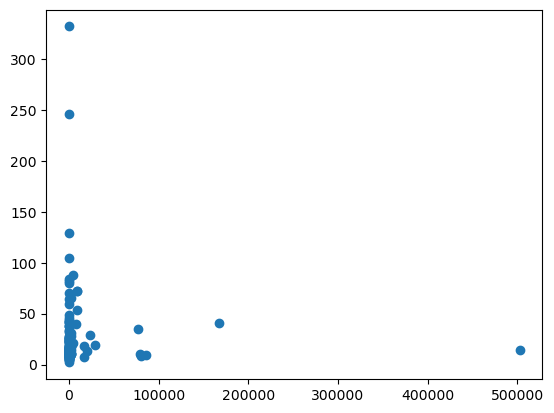

In [43]:
def filter_df_ds(df):
    licenses_keep = ['Creative Commons Attribution 4.0 International']
    count_prev = len(df)
    df = df[df['license'].isin(licenses_keep)]
    count_after = len(df)
    print(f"Filtered datasets by license. Remaining datasets: {count_after}/{count_prev}")
    licenses_removed = df_info[~df_info['license'].isin(licenses_keep)]['license'].value_counts()
    print(f"Removed licenses:\n{licenses_removed}")

    min_rows = 2 
    df = df[df['n_rows'] >= min_rows]
    count_prev = len(df)
    print(f"Removed datasets with less than {min_rows} rows. Remaining datasets: {count_prev}/{count_after}")

    df['n_elements'] = df['n_rows'] * df['n_columns']

    return df

df_filtered = filter_df_ds(df_info)

import matplotlib.pyplot as plt

plt.plot(df_filtered['n_rows'], df_filtered['n_columns'], 'o')

In [57]:
df_info[df_info['topic'] == 'Atmosphere']

,name,description,keywords,license,n_rows,n_columns,topic,doi,id
10,Aerosol size distribution between 90 and 5000 ...,The aerosol size distribution between 90 and 5...,"[aerosol, Antarctica, Neumayer Station, size d...",Creative Commons Attribution 4.0 International,8754,72,Atmosphere,doi:10.1594/PANGAEA.913868,913868
11,Integrated water vapor and temperature profile...,In the frame of the OASIS-YOPP project measure...,[Atmosphere],Creative Commons Attribution 3.0 Unported,0,0,Atmosphere,doi:10.1594/PANGAEA.893188,893188
12,Ultrasonic anemometer on-board wind measuremen...,This dataset consists of wind measurements tak...,"[Arctic, Atmosphere, Polarstern, wind]",Creative Commons Attribution 4.0 International,502615,14,Atmosphere,doi:10.1594/PANGAEA.990495,990495
13,Continuous surface water vapour isotope monito...,This dataset presents the first fully continuo...,"[Antarctica, Continuous isotope monitoring, Pa...",Creative Commons Attribution 4.0 International,17133,18,Atmosphere,doi:10.1594/PANGAEA.939047,939047
14,Aerosol size distribution between 90 and 5000 ...,The aerosol size distribution between 90 and 5...,"[aerosol, Antarctica, size distribution, Spuso]",Creative Commons Attribution 4.0 International,8518,72,Atmosphere,doi:10.1594/PANGAEA.913861,913861
15,Condensation nuclei >3 nm (CN3) measurements a...,Measurements of condensation nuclei greater th...,"[aerosol, biomass burning, CN3, COALA-2020, ne...",Creative Commons Attribution 4.0 International,79941,8,Atmosphere,doi:10.1594/PANGAEA.925555,925555
16,Atmospheric air pressure from Central-western ...,The meteorological database provided herein de...,"[air temperature, Antarctica, Criosfera 1]",Creative Commons Attribution 4.0 International,86307,9,Atmosphere,doi:10.1594/PANGAEA.945294,945294
17,Navopatía Flux Station eddy covariance (EC) da...,Objective:\n-----\nThe objective of this datab...,"[Carbon, latent heat, mangrove, Navopatía, sen...",Creative Commons Attribution-NoDerivs 4.0 Inte...,24079,11,Atmosphere,doi:10.1594/PANGAEA.905663,905663
18,Tethered balloon-borne meteorological measurem...,The tethered balloon system BELUGA (Balloon-bo...,"[ABL, AO2018(MOCCHA), High Arctic, radiation, ...",Creative Commons Attribution 4.0 International,1801,10,Atmosphere,doi:10.1594/PANGAEA.927062,927062
19,Daily meteorological data from automatic weath...,Presented dataset contains meteorological data...,"[automatic weather station, meteorology of pol...",Creative Commons Attribution 4.0 International,2191,17,Atmosphere,doi:10.1594/PANGAEA.969067,969067


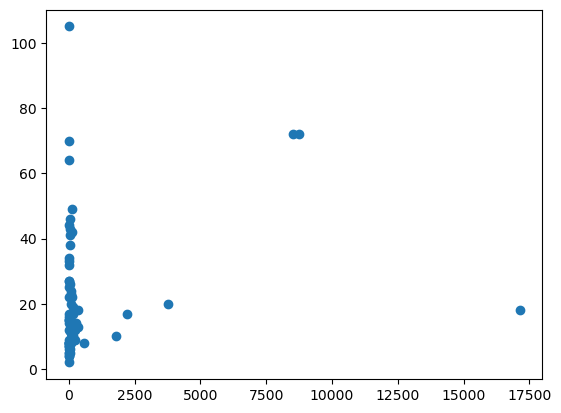

In [59]:
n_datasets_per_topic = 5
## get the top n datasets per topic based on the number of elements (rows * columns)
df_filtered_sorted = df_filtered.sort_values(by='n_elements', ascending=True)
df_top_n_per_topic = df_filtered_sorted.groupby('topic').head(n_datasets_per_topic)
df_top_n_per_topic.reset_index(drop=True, inplace=True)
# df_top_n_per_topic.
plt.plot(df_top_n_per_topic['n_rows'], df_top_n_per_topic['n_columns'], 'o')
# df_filtered_sorted

In [ ]:
df_top_n_per_topic = pd.read_csv(os.path.join(folder_ds, 'sample_20260629_163144_filtered_top5_per_topic.csv'))
df_top_n_per_topic

,name,description,keywords,license,n_rows,n_columns,topic,doi,id,n_elements,citation_key
0,A regional pCO2 climatology of the Baltic Sea,Based on direct surface pCO2 observation and a...,"['Baltic Sea', 'climatology', 'CO2']",Creative Commons Attribution 4.0 International,2,4,Lithosphere,doi:10.1594/PANGAEA.961119,961119,8,bittig2023arpc
1,Underwater video recordings during mesopelagic...,During three cruises in the Mid Atlantic Ridge...,"['mesopelagic fish', 'mesopelagic invertebrates']",Creative Commons Attribution 4.0 International,2,7,Fisheries,doi:10.1594/PANGAEA.931902,931902,14,grimaldo2021uvrd
2,Involving local communities for effective citi...,These three datasets are related to the analys...,"['bushmeat', 'Citizen science', 'community-bas...",Creative Commons Attribution 4.0 International,3,5,Lakes & Rivers,doi:10.1594/PANGAEA.906209,906209,15,elbizri2019ilcf
3,Raw data from Pure-rotational and Vibro-rotati...,The data correspond to measurements along a ve...,"['Experiment', 'extinction retrieval', 'pure-r...",Creative Commons Attribution 4.0 International,2,8,Human Dimensions,doi:10.1594/PANGAEA.931282,931282,16,zentenohernndez2021rdfp
4,"Ground Temperature Map, 2000-2017, Antarctic",The product provides modeled mean annual groun...,"['Antarctic', 'Cryosphere', 'ground temperatur...",Creative Commons Attribution 4.0 International,4,5,Cryosphere,doi:10.1594/PANGAEA.902576,902576,20,obu2019gtma
...,...,...,...,...,...,...,...,...,...,...,...
70,Daily meteorological data from automatic weath...,Presented dataset contains meteorological data...,"['automatic weather station', 'meteorology of ...",Creative Commons Attribution 4.0 International,2191,17,Atmosphere,doi:10.1594/PANGAEA.969067,969067,37247,plenzler2024dmdf
71,A compilation of published pyrite sulfur isoto...,This dataset contains a compilation of the sul...,"['AGE', 'Depth', 'Lithology', 'Methane', 'pyri...",Creative Commons Attribution 4.0 International,3754,20,Geophysics,doi:10.1594/PANGAEA.972993,972993,75080,spruzen2024acop
72,Continuous surface water vapour isotope monito...,This dataset presents the first fully continuo...,"['Antarctica', 'Continuous isotope monitoring'...",Creative Commons Attribution 4.0 International,17133,18,Atmosphere,doi:10.1594/PANGAEA.939047,939047,308394,bagheridastgerdi2021cswv
73,Aerosol size distribution between 90 and 5000 ...,The aerosol size distribution between 90 and 5...,"['aerosol', 'Antarctica', 'size distribution',...",Creative Commons Attribution 4.0 International,8518,72,Atmosphere,doi:10.1594/PANGAEA.913861,913861,613296,weller2020asdb


In [73]:
list_citations = []
list_keys = []

def get_bibtex(doi: str) -> str:
    url = f"https://doi.pangaea.de/{doi}"
    r = requests.get(url, headers={"Accept": "application/x-bibtex"})
    r.raise_for_status()
    return r.text

for row in tqdm(df_top_n_per_topic.itertuples()):
    ds = pds.PanDataSet(row.id)
    data = ds.data
    data.to_csv(os.path.join(folder_ds, 'pangaea_datasets', f"{row.id}.csv"), index=False)

    citation = get_bibtex(row.doi)
    key = citation.split('{')[1].split(',')[0]
    list_citations.append(citation)
    list_keys.append(key)

    time.sleep(0.2)  # To avoid overwhelming the server with requests

df_top_n_per_topic['citation_key'] = list_keys

df_top_n_per_topic.to_csv(os.path.join(folder_ds, 'sample_20260629_163144_filtered_top5_per_topic.csv'), index=False)
## save citations to a text file
with open(os.path.join(folder_ds, 'pangaea_datasets', 'sample_20260629_163144_filtered_top5_citations.bib'), 'w') as f:
    f.write('\n\n'.join(list_citations))

5it [00:03,  1.47it/s]Could not create QC flag dataframe - https://doi.org/10.1594/PANGAEA.954529
75it [00:57,  1.31it/s]
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_96229/948854408.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_n_per_topic['citation_key'] = list_keys


In [10]:
df_top_n_per_topic = pd.read_csv(os.path.join(folder_ds, 'sample_20260629_163144_filtered_top5_per_topic.csv'))

In [21]:
# ds_sampled['by_topic']

In [ ]:
df_table = {x: [] for x in ['Topic', 'Licenses', 'Abstract/keyword present', 'Citations']}
topics = df_top_n_per_topic['topic'].unique()

for t in topics:
    df_topic = df_top_n_per_topic[df_top_n_per_topic['topic'] == t]
    license_counts = df_topic['license'].value_counts()
    if len(license_counts) == 1:
        all_licenses = license_counts.index[0]
    else:
        all_licenses = ', '.join(license_counts.index)
    citations = r"\cite{" + ','.join(df_topic['citation_key']) + "}"
    
    n_success = len(ds_sampled['by_topic'][t])
    n_total = ds_sampled['n_failed'][t] + n_success
    percentage_present = (n_success / n_total) * 100

    df_table['Topic'].append(t.replace('&', r'\&'))
    df_table['Licenses'].append(all_licenses)
    df_table['Abstract/keyword present'].append(percentage_present)
    df_table['Citations'].append(citations)

df_table = pd.DataFrame(df_table)
df_table['Licenses'] = df_table['Licenses'].str.replace('Creative Commons Attribution 4.0 International', 'CC BY 4.0', regex=False)
df_table['Abstract/keyword present'] = df_table['Abstract/keyword present'].round(2).astype(str) + r'\%'
df_table = df_table.sort_values(by='Topic').reset_index(drop=True)

df_table.to_latex(os.path.join(folder_ds, 'sample_20260629_163144_filtered_top5_per_topic_table.tex'), index=False, escape=False,
                  label='tab:pangaea_overview', caption=r"\textbf{Overview of the selected PANGAEA datasets per topic.}")

In [32]:
df_table

,Topic,License,Abstract/keyword present,Citations
0,Agriculture,CC BY 4.0,50.0%,"\cite{rantala2026lpdo,rczkowska2024batt,rantal..."
1,Atmosphere,CC BY 4.0,0.51%,"\cite{gottschalk2021tbmm,plenzler2024dmdf,bagh..."
2,Biological Classification,CC BY 4.0,4.91%,"\cite{kress2022ssit,forster2026sdom,hill2025pr..."
3,Biosphere,CC BY 4.0,22.0%,"\cite{greiffenhagen2026toca,greiffenhagen2026t..."
4,Chemistry,CC BY 4.0,2.03%,"\cite{martnezbraceras2024wmot,schmidt2023pgos,..."
5,Cryosphere,CC BY 4.0,18.18%,"\cite{obu2019gtma,banerjee2022icoc,hecht2024sd..."
6,Ecology,CC BY 4.0,39.29%,"\cite{mckenzie2023ssba,dasadhikari2019ecia,bur..."
7,Fisheries,CC BY 4.0,31.25%,"\cite{grimaldo2021uvrd,apnmolina2020pmit,mille..."
8,Geophysics,CC BY 4.0,32.35%,"\cite{albers2024gobf,massari2026hmco,kster2021..."
9,Human Dimensions,CC BY 4.0,18.52%,"\cite{zentenohernndez2021rdfp,juhls2021swio,be..."


## Audit table

In [108]:
fp_audit_tab = os.path.join(folder_ds, 'audit_coverage_20260710_151402.csv')
df_audit = pd.read_csv(fp_audit_tab)
import numpy as np
col_checks = {
    "name": "Title",
    "description": "Description",
    "keywords": "Keywords",
    "license": "License",
    "temporalCoverage": "Temporal coverage*",
    "spatialCoverage": "Spatial coverage*",
    "supplement_to": "Linked publication*"
}
col_checks = {k: v + ' [\%]' for k, v in col_checks.items()}
for col in col_checks:
    df_audit[col] = np.round(df_audit[col] * 100).astype(int)

df_audit = df_audit.rename(columns={**col_checks, **{'topic': 'Topic'}})
df_audit = df_audit.drop(columns=['n_checked', 'n_skipped'])

df_audit.to_latex(os.path.join(folder_ds, 'audit_coverage_20260710_151402_table.tex'), index=False, escape=False,
                  label='tab:pangaea_audit', caption=r"\textbf{Audit of the selected PANGAEA datasets per topic.} The table shows the percentage of datasets per topic that have the respective metadata property. The columns marked with an asterisk indicate that the property was not present in the metadata of the dataset, but was inferred from the dataset itself. The ``Linked publication'' column indicates whether the dataset has a linked publication in PANGAEA. The percentages are rounded to the nearest integer. The ``ALL'' row shows the overall percentage across all topics.")  

In [94]:
## TMP

tmp_path = '/Users/tplas/data/2026-06-29 cybench/cybench-data/wheat/AR'
assert os.path.exists(tmp_path), f"Path does not exist: {tmp_path}"

len([x for x in os.listdir(tmp_path) if x[0] != '.'])

9